In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from random import randrange
import warnings
from scipy import linalg    
import seaborn as sns
from scipy.stats import linregress
from scipy.spatial import Delaunay
from collections import defaultdict
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from tqdm import tqdm
warnings.filterwarnings('ignore')

datadir = '/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/InferenceScripts/PythonContained/dataout/'
datadirTraj = '/Users/billiemeadowcroft/Dropbox/PostDocCode/AmandaData/DataFrames/'
#datadout = '/Users/billiemeadowcroft/Dropbox/PostDocCode/AmandaData/DataFrames/'
plotsdir='/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/Plots/'
cmap = plt.cm.get_cmap('BuPu')
clrs=["#c7e9b4","#7fcdbb","#41b6c4","#1d91c0","#225ea8","#0c2c84","#c7e9b4","#7fcdbb","#41b6c4","#1d91c0","#225ea8","#0c2c84"]
clrs2=["#fc8d59","#d7301f","#650be3","#272FCD","#318395","#4575b4","#91bfdb","#313695","#4575b4","#313695","#fef0d9","#fdcc8a","#fc8d59","#d7301f","#4575b4","#313695","#313695","#4575b4","#91bfdb","#313695","#4575b4","#313695"]

In [2]:
clrs = [
    "#CF7676",  # Saddle Brown
    '#4682B4',  # Steel Blue
    "#665197",  # Dark Olive Green
    '#A0522D',  # Sienna
    '#B22222',  # Firebrick
    '#228B22',  # Forest Green
    '#D2B48C',  # Tan
    '#6B8E23',  # Olive Drab
    '#DAA520',  # Goldenrod
    '#2F4F4F'   # Dark Slate Gray
]

In [3]:
# outputs vector of size NumBasisFunctions
def laguerre_polynomialsExp(r,NumBasisFunctions,r_mod):
    # Initialize Laguerre*exp(-r) and their derivatives
    L_exp = [np.exp(-r/r_mod), (1 - r) * np.exp(-r/r_mod)]
    dL_exp = [-np.exp(-r/r_mod), (r - 2) * np.exp(-r/r_mod)]

    # Recursively build L_k(r) * exp(-r)
    L_plain = [1.0, 1 - r]  # plain Laguerre polynomials L_k(r)

    for k in range(2, NumBasisFunctions):
        # Compute next Laguerre polynomial
        Lk = ((2*k - 1 - r) * L_plain[k-1] - (k - 1) * L_plain[k-2]) / k
        L_plain.append(Lk)

        # Multiply by exp(-r)
        Lk_exp = Lk * np.exp(-r/r_mod)
        L_exp.append(Lk_exp)

        # Compute the derivative of L_k(r) * exp(-r)
        Dlk = -Lk_exp*np.exp(-r/r_mod) + np.exp(-r/r_mod) * (1/r)* (k*Lk-k*L_plain[k-1])
        dL_exp.append(Dlk)

    #print(np.shape(np.reshape(L_exp,5)))
    return L_exp #, dL_exp


In [4]:
def compute_gr(df, box_size,r_max,nummbins):
    coords = df[['x', 'y']].values
    timesteps = df['timestep'].values
    #N = len(coords)
    NCells = len(np.unique(df['id'].values))
    bins = np.linspace(0, r_max, nummbins)  # Define bins for histogram
    gr = np.zeros(len(bins) - 1)
    AvNs = []
    #Ncounts = 0
    print("Number of particles:",NCells)
    for tt in np.unique(timesteps):
        print(f"Processing timestep {tt} of {np.max(timesteps)}")
        coords_tt = coords[timesteps == tt]
        N_tt = len(coords_tt)
        if N_tt < 2:
            continue
        AvNs.append(N_tt)
        for i in range(N_tt):
            rij = coords_tt - coords_tt[i]
            # Minimum image convention
            #rij -= box_size * np.round(rij / box_size)
            distances = np.linalg.norm(rij, axis=1)
            distances = distances[(distances > 0) & (distances < r_max)]
            hist, _ = np.histogram(distances, bins=bins)
            gr += hist
    # Normalization
    N=np.mean(AvNs) # Average number of particles per frame
    TstepsTot = len(np.unique(timesteps))
    gr = gr/ TstepsTot #average gr per frame
    rho = N / (box_size ** 2) # Average density
    shell_areas = np.pi * (bins[1:] ** 2 - bins[:-1] ** 2)
    gr = gr / ( N * rho * shell_areas)

    r_centers = 0.5 * (bins[1:] + bins[:-1])
    return r_centers, gr, N


def compute_g3(df, box_size,r_max,nummbins):
    coords = df[['x', 'y']].values
    bins = np.linspace(0, r_max, nummbins)  # Define bins for histogram
    dr = bins[1] - bins[0]  # Bin width
    g3 = np.zeros((len(bins)-1, len(bins)-1))
    timesteps = df['timestep'].values
    NCells = len(np.unique(df['id'].values))
    print("Number of particles:",NCells)
    AvNs = []
    for tt in np.unique(timesteps):
        print(f"Processing timestep {tt} of {np.max(timesteps)}")
        coords_tt = coords[timesteps == tt]
        N_tt = len(coords_tt)
        print("Number of particles in this frame:",N_tt)
        if N_tt < 2:
            continue
        AvNs.append(N_tt)
        for i in range(N_tt):
            r_i = coords_tt[i]
            rij = coords_tt - r_i
            #rij -= box_size * np.round(rij / box_size)
            dists_j = np.linalg.norm(rij, axis=1)

            for j in range(N_tt):
                if j == i: continue

                rj_bin = int(dists_j[j] // dr)
                if rj_bin >= len(bins) - 1: continue
                for k in range(N_tt):
                    if k == i or k == j: continue
                    rik = coords_tt[k] - r_i
                    #rik -= box_size * np.round(rik / box_size)
                    rk_bin = int(np.linalg.norm(rik) // dr)
                    if rk_bin >= len(bins) - 1: continue
                    g3[rj_bin, rk_bin] += 1
                    #print("got to adding to g3")
        
    N=np.mean(AvNs) # Average number of particles per frame
    TstepsTot = len(np.unique(timesteps))
    g3 = g3/ TstepsTot #average gr per frame
    # Normalize g3
    # Calculate the normalization factor
    rho = N / (box_size ** 2)
    shell_areas = np.pi * (bins[1:]**2 - bins[:-1]**2)
    
    norm_matrix = np.outer(shell_areas, shell_areas)  # shape (n_bins, n_bins)
    g3Norm = g3 / (N**2 *  rho**2 * norm_matrix)

    return bins, g3Norm, N

In [5]:
def compute_g3_1frame(df, box_size,r_max,nummbins):
    coords_tt = df[['x', 'y']].values
    bins = np.linspace(0, r_max, nummbins)  # Define bins for histogram
    dr = bins[1] - bins[0]  # Bin width
    g3 = np.zeros((len(bins)-1, len(bins)-1))
    #N = len(coords)
    NCells = len(np.unique(df['id'].values))
    
    #bins = np.linspace(0, r_max, nummbins)  # Define bins for histogram
    #gr = np.zeros(len(bins) - 1)
    AvNs = []
    N_tt = len(coords_tt)
    print("Number of particles:",N_tt)
    #if N_tt < 2:
    #    continue
    AvNs.append(N_tt)
    for i in range(N_tt):
        r_i = coords_tt[i]
        rij = coords_tt - r_i
        #rij -= box_size * np.round(rij / box_size)
        dists_j = np.linalg.norm(rij, axis=1)

        for j in range(N_tt):
            if j == i: continue

            rj_bin = int(dists_j[j] // dr)
            if rj_bin >= len(bins) - 1: continue
            for k in range(N_tt):
                if k == i or k == j: continue
                rik = coords_tt[k] - r_i
                #rik -= box_size * np.round(rik / box_size)
                rk_bin = int(np.linalg.norm(rik) // dr)
                if rk_bin >= len(bins) - 1: continue
                g3[rj_bin, rk_bin] += 1
        
    N= N_tt # Average number of particles per frame
    #TstepsTot = len(np.unique(timesteps))
    #gr = gr/ TstepsTot #average gr per frame
    # Normalize g3
    # Calculate the normalization factor
    rho = N / (box_size ** 2)
    shell_areas = np.pi * (bins[1:]**2 - bins[:-1]**2)
    
    norm_matrix = np.outer(shell_areas, shell_areas)  # shape (n_bins, n_bins)
    g3Norm = g3 / (N**2 *  rho**2 * norm_matrix)

    #shell_volume = (4/3) * np.pi * (bins[1:]**3 - bins[:-1]**3)
    #ideal_count = (NCells * (NCells - 1) * (NCells - 2)) / 6  # Number of trip
    #g3a /= N**2  # because of double counting?
    return bins, g3Norm

In [6]:

Times = [1,2,3,4,5]
resultsFile_gr = []
for f in range(5):
    #f+=2
    print("Processing time regime:", Times[f])
    name = "df_cells_D1toD3_ctrl_w1_offset_1_control_N5000_filt_TimeRegime"+ str(Times[f]) + ".csv"
    print(name)
    input_file_path = datadirTraj + name
    Cell_df = pd.read_csv(input_file_path)
    Cell_df = Cell_df.sort_values(by='id').reset_index(drop=True)
    CellInd = Cell_df.index[Cell_df['id'].diff().ne(0)].tolist()
    CellInd.append(len(Cell_df) - 1)

    # Continue with the rest of your function
    Cell_df['timestep'] = Cell_df['timestep'].round(2)
    Cell_df = Cell_df.sort_values(by=['id', 'timestep']).reset_index(drop=True)
    box_size = np.min([Cell_df['x'].max() - Cell_df['x'].min(),Cell_df['y'].max() -Cell_df['y'].min()])
    r_max = box_size
    print("Box size:", box_size)
    numbins = 1000
    # Make a random data set with the same number of particles on average and the same number of timesteps

    # step 1, calculate the average number of particles per frame
    NAvs = []
    for tt in Cell_df['timestep'].unique():
        coords_tt  = Cell_df[Cell_df['timestep'] == tt][['x', 'y']].values
        N_tt = len(coords_tt)
        NAvs.append(N_tt)
    NAv = np.mean(NAvs)
    timesteps = Cell_df['timestep'].unique()
    T = len(timesteps)
    N = int(NAv)  # ensure it's an integer

    total_points = T * N  # make this your single source of truth
    if f==1:
        RandArrayX = np.random.uniform(0, box_size, size=total_points)
        RandArrayY = np.random.uniform(0, box_size, size=total_points)
        RandArrayT = np.repeat(timesteps, N)
        RandArrayID = np.arange(total_points) // N
        print("Average number of particles per frame:", NAv)
        print("length of random array:", len(RandArrayX), len(RandArrayY), len(RandArrayT), len(RandArrayID))
        Rand_df = pd.DataFrame({
            'x': RandArrayX,
            'y': RandArrayY,
            'timestep': RandArrayT,
            'id': RandArrayID
        })
        r_centers_rand, gr_rand, Ncalc_rand = compute_gr(Rand_df, box_size,r_max,numbins)
        print("Av cells per frame in the random:", Ncalc_rand)
        
    r_centers, gr, Ncalc = compute_gr(Cell_df, box_size,r_max,numbins)
    print("Av cells per frame in the original data set:", Ncalc)
    
    # save results in a dictionary
    resultsFile_gr.append({
        'r_centers': r_centers,
        'gr': gr,
        #'r_centers_rand': r_centers_rand,
        #'gr_rand': gr_rand,
        'time_regime': Times[f],
        'N': N,
        'box_size': box_size,
        
    })
        

    

Processing time regime: 1
df_cells_D1toD3_ctrl_w1_offset_1_control_N5000_filt_TimeRegime1.csv
Box size: 1229.67559057441
Number of particles: 772
Processing timestep 13.84 of 16.84
Processing timestep 14.09 of 16.84
Processing timestep 14.34 of 16.84
Processing timestep 14.59 of 16.84
Processing timestep 14.84 of 16.84
Processing timestep 15.09 of 16.84
Processing timestep 15.34 of 16.84
Processing timestep 15.59 of 16.84
Processing timestep 15.84 of 16.84
Processing timestep 16.09 of 16.84
Processing timestep 16.34 of 16.84
Processing timestep 16.59 of 16.84
Processing timestep 16.84 of 16.84
Av cells per frame in the original data set: 342.15384615384613
Processing time regime: 2
df_cells_D1toD3_ctrl_w1_offset_1_control_N5000_filt_TimeRegime2.csv
Box size: 1256.496654700435
Average number of particles per frame: 1366.55
length of random array: 27320 27320 27320 27320
Number of particles: 20
Processing timestep 16.84 of 21.58
Processing timestep 17.09 of 21.58
Processing timestep 17.3

In [14]:
# save the results to a file
r_centers = resultsFile_gr[0]['r_centers']
gr = resultsFile_gr[0]['gr']
f = open(plotsdir + 'gr_results.txt', 'w')
f.write("r_centers, gr \n")
for i in range(len(r_centers)):
    f.write(f"{r_centers[i]}, {gr[i]}\n")
f.close()


Box size: 1301.3236152500026


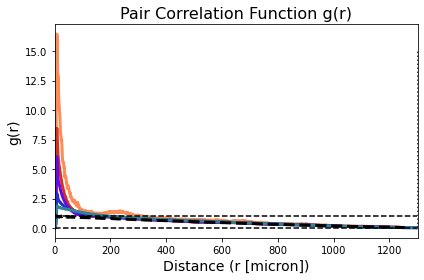

In [7]:
print("Box size:", box_size)
fig, ax = plt.subplots(figsize=(6, 4))
for f in range(len(resultsFile_gr)): #
    r_centers = resultsFile_gr[f]['r_centers']
    #r_centers_rand = resultsFile_gr[f]['r_centers_rand']
    #gr_rand = resultsFile_gr[f]['gr_rand']
    gr = resultsFile_gr[f]['gr']
    ax.plot(r_centers, gr, label=f'Time Regime {resultsFile_gr[f]["time_regime"]}',linewidth = 3, color=clrs2[f])
    if f==4:
        ax.plot(r_centers_rand, gr_rand, linestyle='--', label=f'Randomized Data, Time Regime {resultsFile_gr[f]["time_regime"]}', linewidth = 3,color='black')
ax.plot(r_centers, np.ones_like(r_centers), linestyle='--', color='black', linewidth=1.5)
ax.plot(r_centers, np.zeros_like(r_centers), linestyle='--', color='black', linewidth=1.5)
ax.plot([box_size, box_size], [0, 15], linestyle=':', color='black', linewidth=1.5)
text = "box size"
#ax.text(box_size - 50, 1.5, text, fontsize=12, color='black', rotation=90, ha='left', va='bottom')
ax.set_xlabel('Distance (r [micron])',fontsize=14)
ax.set_ylabel('g(r)', fontsize=14)
ax.set_title('Pair Correlation Function g(r)', fontsize=16)
ax.set_xlim(0, box_size)
#ax.set_ylim([-0.05, 10])
#ax.set_ylim([-0.05,1.1])
# Load the data with proper types
#ax.legend(frameon=False,fontsize=12, loc=[0.2,0.3])
fig.tight_layout()

Plotting F(r) and g(r) from existing data

In [80]:
name = "df_cells_D1toD3_ctrl_w1_offset_1_control_N5000_filt_TimeRegime"+ str(Times[0]) + ".csv"
input_file_path = datadirTraj + name
Cell_df = pd.read_csv(input_file_path)
Cell_df = Cell_df.sort_values(by='id').reset_index(drop=True)
box_size = np.min([Cell_df['x'].max() - Cell_df['x'].min(),Cell_df['y'].max() -Cell_df['y'].min()])
r_max = box_size
# get 1st time step
Cell_df0 = Cell_df[Cell_df['timestep']== Cell_df['timestep'].min()]
numbins = 100
print("Cell_df",Cell_df0.head())
#how many cells in the first time step?
NCells = len(np.unique(Cell_df0['id'].values))
print("Number of cells in the first time step:", NCells)
N=NCells
total_points = N
# make a random data set with the same number of particles on average and the same number of timesteps
RandArrayX = np.random.uniform(0, box_size, size=total_points)
RandArrayY = np.random.uniform(0, box_size, size=total_points)
RandArrayT = np.repeat(1, N)
RandArrayID = np.arange(total_points) #// N
print("Average number of particles per frame:", NAv)
print("length of random array:", len(RandArrayX), len(RandArrayY), len(RandArrayT), len(RandArrayID))
Rand_df = pd.DataFrame({
    'x': RandArrayX,
    'y': RandArrayY,
    'timestep': RandArrayT,
    'id': RandArrayID
})

bins, g3Norm = compute_g3_1frame(Cell_df0, box_size,r_max,numbins)
bins_rand, g3Norm_rand = compute_g3_1frame(Rand_df, box_size,r_max,numbins)

Cell_df     timestep  id           x            y
0      13.84   1  181.830094   884.296144
24     13.84   2  361.202498   863.162422
49     13.84   4  305.724402   652.723863
62     13.84   5  190.650154  1193.571451
75     13.84   6  311.802834   967.593553
Number of cells in the first time step: 66
Average number of particles per frame: 3215.6875
length of random array: 66 66 66 66
Number of particles: 66
Number of particles: 66


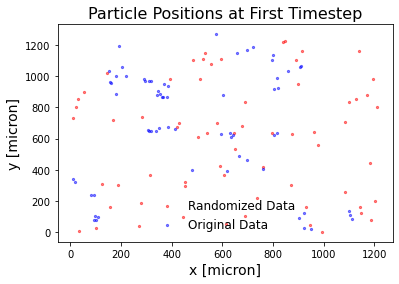

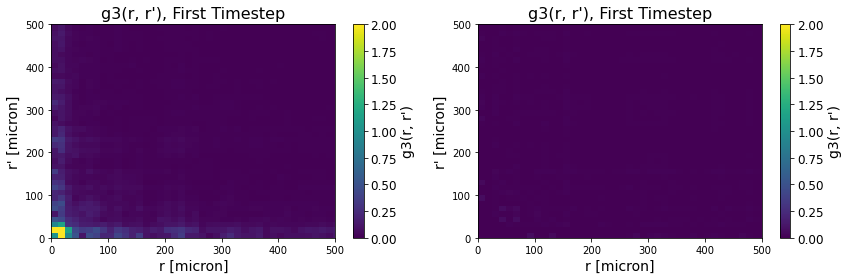

In [90]:
fig,ax = plt.subplots(figsize=(6, 4))
ax.scatter(RandArrayX, RandArrayY, s=5, color='red', alpha=0.5, label='Randomized Data')
ax.scatter(Cell_df0['x'], Cell_df0['y'], s=5, color='blue', alpha=0.5, label='Original Data')
ax.set_xlabel('x [micron]', fontsize=14)
ax.set_ylabel('y [micron]', fontsize=14)
ax.set_title('Particle Positions at First Timestep', fontsize=16)
ax.legend(frameon=False, fontsize=12)

fig2,ax2 = plt.subplots(1,2,figsize=(12, 4))
ax2[0].imshow(g3Norm, extent=(bins[0], bins[-1], bins[0], bins[-1]), origin='lower', cmap='viridis', aspect='auto',vmin = 0,vmax = 2)
ax2[1].imshow(g3Norm_rand, extent=(bins_rand[0], bins_rand[-1], bins_rand[0], bins_rand[-1]), origin='lower', cmap='viridis', aspect='auto',vmin = 0,vmax = 2)
for i in range(2):
    ax2[i].set_xlabel('r [micron]', fontsize=14)
    ax2[i].set_ylabel('r\' [micron]', fontsize=14)
    ax2[i].set_title('g3(r, r\'), First Timestep', fontsize=16)
    #ax2[i].set_xlim(0, box_size)
    #ax2[i].set_ylim(0, box_size)
    ax2[i].set_xlim([0,500])
    ax2[i].set_ylim([0,500])
    #ax2[i].colorbar(label='g3(r, r\')', ax=ax2[i])
# add colorbar to the first subplot
# set color bar with max and min values

cbar = fig2.colorbar(ax2[0].images[0], ax=ax2[0], orientation='vertical')
cbar.set_label('g3(r, r\')', fontsize=14)
cbar.ax.tick_params(labelsize=12)

cbar = fig2.colorbar(ax2[1].images[0], ax=ax2[1], orientation='vertical')
cbar.set_label('g3(r, r\')', fontsize=14)
cbar.ax.tick_params(labelsize=12)
fig2.tight_layout()

In [115]:
Times = [1,2,3,4,5]
resultsFile_gr3 = []
for f in range(1):
    #f+=2
    print("Processing time regime:", Times[f])
    name = "df_cells_D1toD3_ctrl_w1_offset_1_control_N5000_filt_TimeRegime"+ str(Times[f]) + ".csv"
    input_file_path = datadirTraj + name
    Cell_df = pd.read_csv(input_file_path)
    Cell_df = Cell_df.sort_values(by='id').reset_index(drop=True)
    #CellInd = Cell_df.index[Cell_df['id'].diff().ne(0)].tolist()
    #CellInd.append(len(Cell_df) - 1)

    # Continue with the rest of your function
    Cell_df['timestep'] = Cell_df['timestep'].round(2)
    Cell_df = Cell_df.sort_values(by=['id', 'timestep']).reset_index(drop=True)

    # get 1st two timesteps
    #Cell_df = Cell_df[Cell_df['timestep'].isin(Cell_df['timestep'].unique()[:2])]
    #Cell_df = Cell_df[Cell_df['timestep']== Cell_df['timestep'].min()]
    
    box_size = np.min([Cell_df['x'].max() - Cell_df['x'].min(),Cell_df['y'].max() -Cell_df['y'].min()])
    r_max = box_size
    print("Box size:", box_size)
    numbins = 100
    # Make a random data set with the same number of particles on average and the same number of timesteps

    # step 1, calculate the average number of particles per frame
    NAvs = []
    for tt in Cell_df['timestep'].unique():
        coords_tt  = Cell_df[Cell_df['timestep'] == tt][['x', 'y']].values
        print(f"Processing timestep {tt} of {np.max(Cell_df['timestep'].unique())} with {len(coords_tt)} particles")
        N_tt = len(coords_tt)
        NAvs.append(N_tt)
    NAv = np.mean(NAvs)
    timesteps = Cell_df['timestep'].unique()
    T = len(timesteps)
    N = int(NAv)  # ensure it's an integer

    total_points = T * N  # make this your single source of truth
    #if f==1:
    RandArrayX = np.random.uniform(0, box_size, size=total_points)
    RandArrayY = np.random.uniform(0, box_size, size=total_points)
    RandArrayT = np.repeat(timesteps, N)
    RandArrayID = np.arange(total_points) // N
    print("Average number of particles per frame:", NAv)
    print("length of random array:", len(RandArrayX), len(RandArrayY), len(RandArrayT), len(RandArrayID))
    Rand_df = pd.DataFrame({
        'x': RandArrayX,
        'y': RandArrayY,
        'timestep': RandArrayT,
        'id': RandArrayID
    })
    #r_centers_rand, gr_rand, Ncalc_rand = compute_g3(Rand_df, box_size,r_max,numbins)
    print("Av cells per frame in the random:", Ncalc_rand)
        
    r_centers, gr, Ncalc = compute_g3(Cell_df, box_size,r_max,numbins)
    print("Av cells per frame in the original data set:", Ncalc)
    
    # save results in a dictionary
    resultsFile_gr3.append({
        'r_centers': r_centers,
        'gr': gr,
        'r_centers_rand': r_centers_rand,
        'gr_rand': gr_rand,
        'time_regime': Times[f],
        'N': N,
        'box_size': box_size,
        
    })
        

    

Processing time regime: 1
Box size: 1229.67559057441
Processing timestep 13.84 of 16.84 with 66 particles
Processing timestep 14.09 of 16.84 with 88 particles
Processing timestep 14.34 of 16.84 with 117 particles
Processing timestep 14.59 of 16.84 with 149 particles
Processing timestep 14.84 of 16.84 with 184 particles
Processing timestep 15.09 of 16.84 with 233 particles
Processing timestep 15.34 of 16.84 with 287 particles
Processing timestep 15.59 of 16.84 with 357 particles
Processing timestep 15.84 of 16.84 with 433 particles
Processing timestep 16.09 of 16.84 with 507 particles
Processing timestep 16.34 of 16.84 with 602 particles
Processing timestep 16.59 of 16.84 with 673 particles
Processing timestep 16.84 of 16.84 with 752 particles
Average number of particles per frame: 342.15384615384613
length of random array: 4446 4446 4446 4446
Av cells per frame in the random: 77.0
Number of particles: 772
Processing timestep 13.84 of 16.84
Number of particles in this frame: 66
Processi

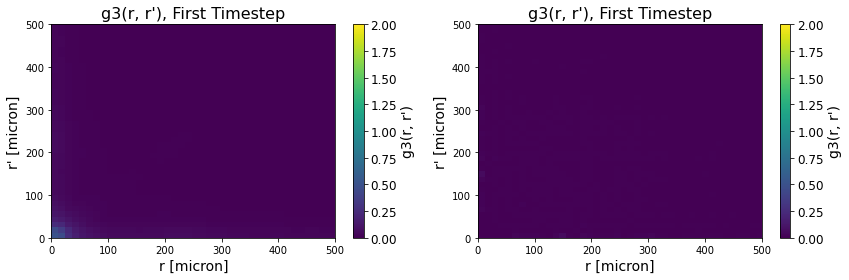

In [126]:
fig, ax = plt.subplots(1,2,figsize=(12, 4))
for f in range(len(resultsFile_gr3)): #
    r_centers = resultsFile_gr3[f]['r_centers']
    r_centers_rand = resultsFile_gr3[f]['r_centers_rand']
    gr_rand = resultsFile_gr3[f]['gr_rand']
    gr = resultsFile_gr3[f]['gr']
    # save results
    bins = resultsFile_gr3[f]['r_centers']
    bins_rand = resultsFile_gr3[f]['r_centers_rand']
    g3Norm = resultsFile_gr3[f]['gr']
    
    g3Norm_rand = resultsFile_gr3[f]['gr_rand']
    f = open(plotsdir + 'g3_results.txt', 'a')
    #f.write(f"Time Regime {resultsFile_gr3[f]['time_regime']}:\n")
    #f.write(f"r_centers: {r_centers}\n")
    f.write(f"g3: {g3Norm}\n")
    #f.write(f"r_centers_rand: {r_centers_rand}\n")
    #f.write(f"g3_rand: {g3Norm_rand}\n")
    #f.write(f"N: {resultsFile_gr3[f]['N']}\n")
    #f.write(f"box_size: {resultsFile_gr3[f]['box_size']}\n")
    f.close()
    ax[0].imshow(g3Norm, extent=(bins[0], bins[-1], bins[0], bins[-1]), origin='lower', cmap='viridis', aspect='auto',vmin = 0,vmax = 2)
    ax[1].imshow(g3Norm_rand, extent=(bins_rand[0], bins_rand[-1], bins_rand[0], bins_rand[-1]), origin='lower', cmap='viridis', aspect='auto',vmin = 0,vmax = 2)
    #ax.plot(r_centers, gr, label=f'Time Regime {resultsFile_gr[f]["time_regime"]}',linewidth = 3, color=clrs2[f])
    #if f==4:
    #    ax.plot(r_centers_rand, gr_rand, linestyle='--', label=f'Randomized Data, Time Regime {resultsFile_gr[f]["time_regime"]}', linewidth = 3,color='black')
#ax.plot(r_centers, np.ones_like(r_centers), linestyle='--', color='black', linewidth=1.5)
#ax.plot(r_centers, np.zeros_like(r_centers), linestyle='--', color='black', linewidth=1.5)
#ax.plot([box_size, box_size], [0, 15], linestyle=':', color='black', linewidth=1.5)
text = "box size"
#ax.text(box_size - 50, 1.5, text, fontsize=12, color='black', rotation=90, ha='left', va='bottom')
#ax[0].set_xlim(500, box_size)
#ax.set_ylim([-0.05, 10])
#ax[0].set_ylim([-0.05,1.1])
cbar = fig2.colorbar(ax[1].images[0], ax=ax[1], orientation='vertical')
cbar.set_label('g3(r, r\')', fontsize=14)
cbar.ax.tick_params(labelsize=12)
cbar = fig2.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical')
cbar.set_label('g3(r, r\')', fontsize=14)
cbar.ax.tick_params(labelsize=12)
for i in range(2):
    ax[i].set_xlim([0,500])
    ax[i].set_ylim([0,500])
    ax[i].set_xlabel('r [micron]', fontsize=14)
    ax[i].set_ylabel('r\' [micron]', fontsize=14)
    ax[i].set_title('g3(r, r\'), First Timestep', fontsize=16)
    #ax2[i].set_xlim(0, box_size)
    #ax2[i].set_ylim(0, box_size)
#ax.legend(frameon=False,fontsize=12, loc=[0.2,0.3])
fig.tight_layout()

In [129]:
f = open(plotsdir + 'g3_results.txt', 'w')
for row in range(len(bins)-1):
    f.write(f"{bins[row]} {g3Norm[row]}\n")
f.close()
    

In [ ]:
name0 = 'my_results_3_ErrCorr'
Bm05 = np.load(datadir+name0+"_Bm05.dat.npy")
force_coeffs = np.load(datadir+name0+"_Force_coeffs.dat.npy")
Rhist = np.load(datadir+name0+"_Rhist.dat.npy")
#print("force_coeffs",force_coeffs)
#print("Bm05",Bm05)
# Load scalar parameters
params = pd.read_csv(datadir+name0+"_params.dat")
r_mod,r_nt,r_n1,r_mode = float(params.loc[0, 'r_mod']),float(params.loc[0, 'R_NT']),float(params.loc[0, 'R_N1']),float(params.loc[0, 'R_mode'])
NumBasisFunctions = int(params.loc[0, 'NumBasisFunctions'])
NumBins = 600
if r_nt!=r_nt: # nan value
    r_centers = np.linspace(0, 600, NumBins)
else:
    r_centers = np.linspace(0, 3*r_nt, NumBins)
CCs = np.zeros((NumBasisFunctions,NumBins))

for k, r in enumerate(r_centers):
    b = laguerre_polynomialsExp(r,NumBasisFunctions,r_mod)
    c = Bm05 @ b
    CCs[:,k] = c
    
Finfer = force_coeffs.dot(CCs)
RhistA = np.array(Rhist)
RhistA, _ = np.histogram(RhistA, bins=r_centers)
IndexRhistA = np.where(RhistA > 100)[0]


Plotting F(r) and R_histogram

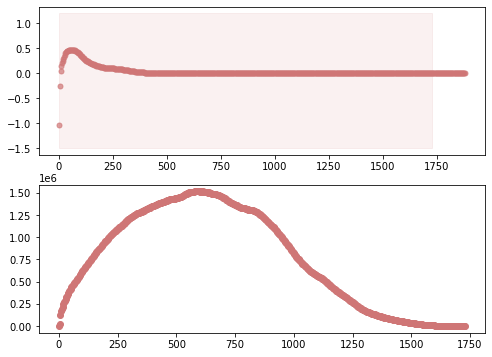

In [12]:
Rbins = 0.5 * (r_centers[:-1] + r_centers[1:])
fig, ax = plt.subplots(2, figsize=(8, 6))
ax[0].plot(Rbins, Finfer[0,:-1], marker='o', alpha=0.7, ms=5, 
                color=clrs[0], linestyle='',label = name0)

ax[1].plot(r_centers[np.min(IndexRhistA):np.max(IndexRhistA)+1], RhistA[np.min(IndexRhistA):np.max(IndexRhistA)+1], marker='o', color=clrs[0], linestyle='', label='Histogram of Pairwise Distances')
#ax[1].hist(Rhist, bins=r_centers, density=False, color=clrs[0], alpha=0.5, label='Pairwise Distances')
ax[0].fill_between([r_centers[np.min(IndexRhistA)],r_centers[np.max(IndexRhistA)+1]],[-1.5,-1.5],[1.2,1.2], color=clrs[0], alpha=0.1, label='>100 DP')

Fetch dataframe and get some instances in time

In [81]:
name = "df_cells_D1toD3_ctrl_w1_offset_1_control_N400_filt.csv"
input_file_path = datadirTraj + name
Cell_df = pd.read_csv(input_file_path)
Cell_df = Cell_df.sort_values(by='id').reset_index(drop=True)
CellInd = Cell_df.index[Cell_df['id'].diff().ne(0)].tolist()
CellInd.append(len(Cell_df) - 1)

# Continue with the rest of your function
Cell_df['timestep'] = Cell_df['timestep'].round(2)
Cell_df = Cell_df.sort_values(by=['id', 'timestep']).reset_index(drop=True)



Plot only cell structure at the two timepoints

number of cells in chosen timestep: 97


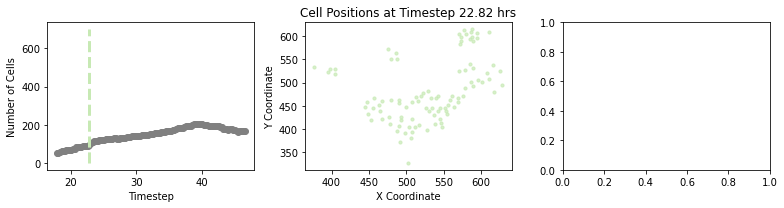

In [84]:
Cell_df = Cell_df.sort_values(by=['timestep']).reset_index(drop=True)

fig,ax = plt.subplots(1,3,figsize=(11, 3))
timesteps = Cell_df['timestep'].unique()
steps = [20,100]
num_cells_per_timestep = Cell_df.groupby('timestep')['id'].nunique().reindex(timesteps, fill_value=0)
ax[0].plot(timesteps, num_cells_per_timestep, marker='o', color='grey', linestyle='-', label='Number of Cells per Timestep')
ax[0].set_xlabel('Timestep')
ax[0].set_ylabel('Number of Cells')

for f in range(1):
    All_pairwise_r = []
    TimestepChosen = steps[f]
    ax[0].plot([timesteps[TimestepChosen],timesteps[TimestepChosen]],[0,700], color=clrs[f], linewidth = 3,linestyle='--', label='Chosen early timestep')
    Cell_df_chosen = Cell_df[Cell_df['timestep'] == timesteps[TimestepChosen]]
    print("number of cells in chosen timestep:", len(Cell_df_chosen))
    ax[f+1].scatter(Cell_df_chosen['x'], Cell_df_chosen['y'],  color = clrs[f], s=10, alpha=0.7)
    ax[f+1].set_xlabel('X Coordinate')
    ax[f+1].set_ylabel('Y Coordinate')
    ax[f+1].set_title('Cell Positions at Timestep {} hrs'.format(timesteps[TimestepChosen]))
fig.tight_layout()

Additionally plot hist(r) and g(r)

number of cells in chosen timestep: 97


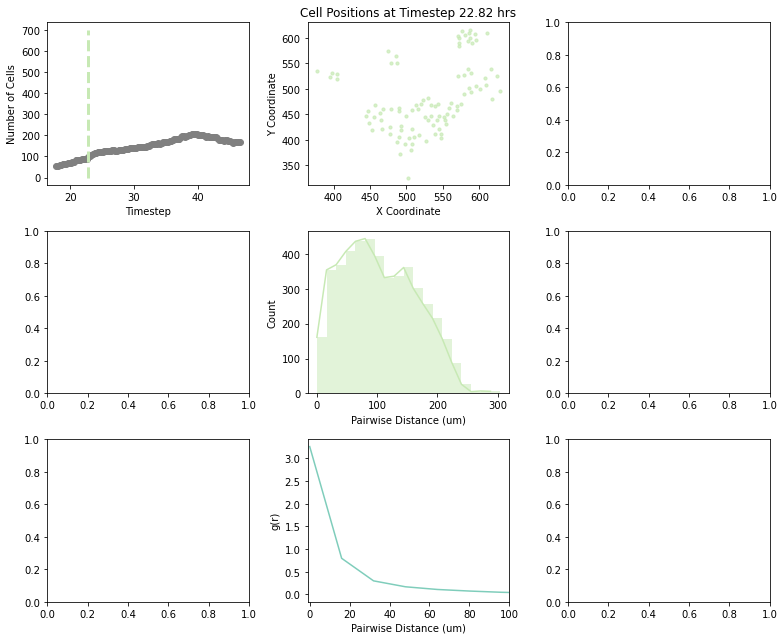

In [88]:
Cell_df = Cell_df.sort_values(by=['timestep']).reset_index(drop=True)

fig,ax = plt.subplots(3,3,figsize=(11, 9))
#plot timesteps
timesteps = Cell_df['timestep'].unique()
steps = [20,100]
num_cells_per_timestep = Cell_df.groupby('timestep')['id'].nunique().reindex(timesteps, fill_value=0)
ax[0,0].plot(timesteps, num_cells_per_timestep, marker='o', color='grey', linestyle='-', label='Number of Cells per Timestep')

ax[0,0].set_xlabel('Timestep')
ax[0,0].set_ylabel('Number of Cells')

for f in range(1):
    All_pairwise_r = []
    TimestepChosen = steps[f]
    ax[0,0].plot([timesteps[TimestepChosen],timesteps[TimestepChosen]],[0,700], color=clrs[f], linewidth = 3,linestyle='--', label='Chosen early timestep')
    Cell_df_chosen = Cell_df[Cell_df['timestep'] == timesteps[TimestepChosen]]
    print("number of cells in chosen timestep:", len(Cell_df_chosen))
    ax[0,f+1].scatter(Cell_df_chosen['x'], Cell_df_chosen['y'],  color = clrs[f], s=10, alpha=0.7)
    for i in range(len(Cell_df_chosen)):
        for j in range(i + 1, len(Cell_df_chosen)):
            dx = Cell_df_chosen.iloc[i]['x'] - Cell_df_chosen.iloc[j]['x']
            dy = Cell_df_chosen.iloc[i]['y'] - Cell_df_chosen.iloc[j]['y']
            distance = np.sqrt(dx**2 + dy**2)
            All_pairwise_r.append(distance)
    NumBins = 20
    rbins = np.linspace(0,np.max(All_pairwise_r), NumBins)
    ax[1,f+1].hist(All_pairwise_r, bins=rbins, density=False, color=clrs[f], alpha=0.5, label='Pairwise Distances at Timestep {}'.format(timesteps[TimestepChosen]))
    # Count histogram in each bin
    hist_counts, _ = np.histogram(All_pairwise_r, bins=rbins)
    ax[1,f+1].plot(rbins[:-1], hist_counts, color=clrs[f], linestyle='-', label='Histogram of Pairwise Distances')
    gr = calculate_gr(rbins,hist_counts,len(Cell_df_chosen))
    ax[2,f+1].plot(rbins[:-1], gr, color=clrs[1], linestyle='-', label='g(r) at Timestep {}'.format(timesteps[TimestepChosen]))
    ax[2,f+1].set_xlim([-1,100])
    ax[0,f+1].set_xlabel('X Coordinate')
    ax[0,f+1].set_ylabel('Y Coordinate')
    ax[1,f+1].set_xlabel('Pairwise Distance (um)')
    ax[1,f+1].set_ylabel('Count')
    ax[2,f+1].set_xlabel('Pairwise Distance (um)')
    ax[2,f+1].set_ylabel('g(r)')
    ax[0,f+1].set_title('Cell Positions at Timestep {} hrs'.format(timesteps[TimestepChosen]))
fig.tight_layout()


Calculate g(r) and g3(r,r') at these timepoints. For only 97 cells this takes 8 minutes...

In [89]:
#creating 2D histogram of g3
g3_count = np.zeros((NumBins, NumBins))
Ncells = len(Cell_df_chosen)
rbins = np.linspace(0,np.max(All_pairwise_r), NumBins)
dr = rbins[1] - rbins[0]  # Bin width
for i in range(Ncells):
    print("done with cell", i+1, "of", Ncells)
    for j in range(Ncells):
        if j == i: continue
        dx = Cell_df_chosen.iloc[i]['x'] - Cell_df_chosen.iloc[j]['x']
        dy = Cell_df_chosen.iloc[i]['y'] - Cell_df_chosen.iloc[j]['y']
        rij = np.sqrt(dx**2 + dy**2)
        #rij = np.linalg.norm(pos[i] - pos[j])
        bin_r = int(rij / dr)
        if bin_r >= NumBins: continue

        for k in range(Ncells):
            if k == i or k == j: continue
            dx = Cell_df_chosen.iloc[i]['x'] - Cell_df_chosen.iloc[k]['x']
            dy = Cell_df_chosen.iloc[i]['y'] - Cell_df_chosen.iloc[k]['y']
            rik = np.sqrt(dx**2 + dy**2)
            bin_rp = int(rik / dr)
            if bin_rp >= NumBins: continue

            g3_count[bin_r, bin_rp] += 1

done with cell 1 of 97
done with cell 2 of 97
done with cell 3 of 97
done with cell 4 of 97
done with cell 5 of 97
done with cell 6 of 97
done with cell 7 of 97
done with cell 8 of 97
done with cell 9 of 97
done with cell 10 of 97
done with cell 11 of 97
done with cell 12 of 97
done with cell 13 of 97
done with cell 14 of 97
done with cell 15 of 97
done with cell 16 of 97
done with cell 17 of 97
done with cell 18 of 97
done with cell 19 of 97
done with cell 20 of 97
done with cell 21 of 97
done with cell 22 of 97
done with cell 23 of 97
done with cell 24 of 97
done with cell 25 of 97
done with cell 26 of 97
done with cell 27 of 97
done with cell 28 of 97
done with cell 29 of 97
done with cell 30 of 97
done with cell 31 of 97
done with cell 32 of 97
done with cell 33 of 97
done with cell 34 of 97
done with cell 35 of 97
done with cell 36 of 97
done with cell 37 of 97
done with cell 38 of 97
done with cell 39 of 97
done with cell 40 of 97
done with cell 41 of 97
done with cell 42 of 97
d

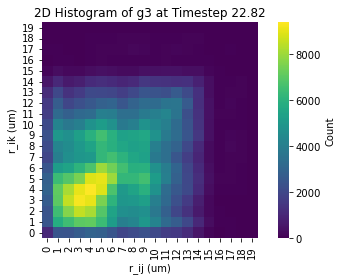

In [91]:
fig,ax = plt.subplots(1,1,figsize=(6, 4))
sns.heatmap(g3_count, cmap='viridis', ax=ax, cbar_kws={'label': 'Count'}, square=True)
ax.invert_yaxis()
ax.set_xlabel('r_ij (um)')
ax.set_ylabel('r_ik (um)')
ax.set_title('2D Histogram of g3 at Timestep {}'.format(timesteps[TimestepChosen]))
fig.tight_layout()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


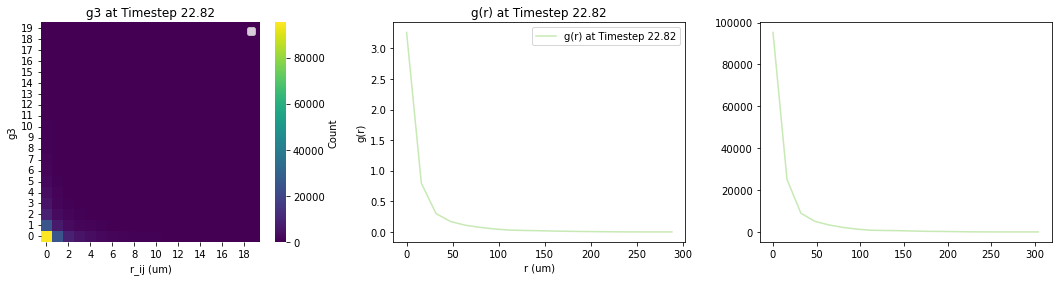

In [102]:
# Calculate g3 and g1

g3, gr = calculate_g3_g1(rbins, g3_count, hist_counts, len(Cell_df_chosen))
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.heatmap(g3, cmap='viridis', ax=ax[0], cbar_kws={'label': 'Count'}, square=True,)
ax[0].invert_yaxis()
#ax[0].plot(rbins, g3[:, 0], color=clrs[1], linestyle='-', label='g3(r_ij, r_ik) at Timestep {}'.format(timesteps[TimestepChosen]))
ax[1].plot(rbins[:-1], gr, color=clrs[0], linestyle='-', label='g(r) at Timestep {}'.format(timesteps[TimestepChosen]))
ax[2].plot(rbins, g3[:,0], color=clrs[0], linestyle='-', label='g(r) at Timestep {}'.format(timesteps[TimestepChosen]))
ax[0].set_xlabel('r_ij (um)')
ax[0].set_ylabel('g3')
ax[0].set_title('g3 at Timestep {}'.format(timesteps[TimestepChosen]))
ax[0].legend()
ax[1].set_xlabel('r (um)')
ax[1].set_ylabel('g(r)')
ax[1].set_title('g(r) at Timestep {}'.format(timesteps[TimestepChosen]))
ax[1].legend()
fig.tight_layout()

In [ ]:
# Converting Rhist to g(r)
def calculate_gr(rbins,rcount,total_particles):
    dr = rbins[1] - rbins[0]  # Bin width
    rbin_centers = rbins[:-1] + dr / 2  # Bin centers
    # Calculate ideal gas density (particles per unit volume)
    max_distance = np.max(rbins)
    volume = (4/3) * np.pi * max_distance**3
    rho = total_particles / volume

    
    # Calculate normalization (expected number of particles in ideal gas)
    norm = 4 * np.pi * rbin_centers**2 * dr * rho
    # Number of possible pairs
    n_pairs = total_particles * (total_particles - 1) / 2
    # Calculate g(r)
    gr = rcount / (norm * n_pairs)
    
    return gr

def calculate_g3_g1(rbins, g3count, rcount, total_particles):
    dr = rbins[1] - rbins[0]
    r_centers = rbins[:-1] + dr / 2
    #r_centers = rbins # + dr/2
    max_distance = np.max(rbins)
    volume = (4/3) * np.pi * max_distance**3
    rho = total_particles / volume
    #n_triplets = total_particles * (total_particles - 1) * (total_particles - 2)
    gr = None
    if rcount is not None:
        n_pairs = total_particles * (total_particles - 1) / 2
        norm = 4 * np.pi * r_centers**2 * dr * rho
        gr = rcount / (norm * n_pairs)
        

    g3 = np.zeros_like(g3count, dtype=float)
    for i, r in enumerate(r_centers):
        for j, rp in enumerate(r_centers):
            shell_volume = (4*np.pi * r**2 * dr) * (4*np.pi * rp**2 * dr)
            ideal_count = rho**2 * shell_volume
            g3[i, j] = g3count[i, j] / (ideal_count * total_particles)

    return g3,gr